# FastF1 – AML Project (2025 Season)
**Group 6:** Aritz Ryan San Sebastian · Nico Azcarate · Jon Larrañaga

Full pipeline in a single notebook:
1. **Data Loading** – download all 2025 race sessions (laps, telemetry, weather, results)
2. **Class Imbalance** – SMOTE / ADASYN / NearMiss / Tomek / ENN / Youden-J threshold
3. **Data Augmentation** – jitter / scaling / magnitude & time warping / window slicing
4. **Data Imputation** – mean / median / LOCF / KNN / MICE-BayesRidge / MICE-RF / MissForest

> Run cells **top-to-bottom** on first use. Subsequent runs are fast thanks to the FastF1 local cache.
> Car setups are **not available** via the FastF1 API (team-confidential data).

## 0. Setup — Imports & Configuration

In [1]:
%matplotlib inline
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

import fastf1

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.ensemble         import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy            import DummyClassifier
from sklearn.metrics          import (
    classification_report, f1_score, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, mean_squared_error,
)
from sklearn.linear_model     import BayesianRidge
from sklearn.experimental     import enable_iterative_imputer  # noqa
from sklearn.impute           import SimpleImputer, KNNImputer, IterativeImputer

from imblearn.over_sampling   import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling  import (RandomUnderSampler, NearMiss,
                                      TomekLinks, EditedNearestNeighbours)
from imblearn.combine         import SMOTEENN

# ── Paths & output directories
CACHE_DIR = "cache"
DATA_DIR  = "data"
OUT_CI    = "outputs/class_imbalance"
OUT_AUG   = "outputs/data_augmentation"
OUT_IMP   = "outputs/imputation"
for _d in [CACHE_DIR, DATA_DIR, OUT_CI, OUT_AUG, OUT_IMP]:
    os.makedirs(_d, exist_ok=True)

fastf1.Cache.enable_cache(CACHE_DIR)

# ── Shared constants
YEAR         = 2025
FEATURE_COLS = ["Speed", "Throttle", "Brake", "RPM", "nGear", "DRS"]
RANDOM_STATE = 42
rng          = np.random.default_rng(RANDOM_STATE)

# ── Section 02 – Class Imbalance
MAX_ROWS   = 200_000   # stratified sub-sample cap (None = full dataset)
ROC_POINTS = 200       # fixed FPR grid resolution for stored ROC curves
RF_TREES   = 50        # RandomForest trees

# ── Section 04 – Data Imputation
MISSING_RATE = 0.10    # synthetic MCAR masking rate for evaluation

# ── Optional memory reporter  (uv add psutil)
try:
    import psutil as _ps
    def _mem(): return f"  [{_ps.Process().memory_info().rss/1e9:.1f} GB RSS]"
except ImportError:
    def _mem(): return ""

print("Setup complete.")

Setup complete.


---
## 1. Data Loading
Downloads and caches all 2025 Race sessions via FastF1.

| Output file | Contents |
|---|---|
| `data/laps.csv` | Per-lap timing, tyre, position + weather merged by session time |
| `data/weather.csv` | Raw weather time-series per round |
| `data/results.csv` | Race results + driver info (grid position, points, Q1/Q2/Q3) |
| `data/race_control.csv` | Race control messages (safety car, flags, incidents) |
| `data/telemetry.csv` | Raw telemetry (Speed, Throttle, Brake, RPM, DRS, X/Y/Z) |
| `data/telemetry_labelled.csv` | Telemetry + `Is_Anomaly` column |

### Column definitions

In [2]:
LAP_COLS = [
    # Identity
    "Driver", "DriverNumber", "Team",
    # Timing
    "LapNumber", "LapTime",
    "Sector1Time", "Sector2Time", "Sector3Time",
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime",
    "LapStartTime", "LapStartDate",
    # Speed traps
    "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    # Tyre
    "Compound", "TyreLife", "FreshTyre", "Stint",
    # Pit
    "PitOutTime", "PitInTime",
    # Race position & status
    "Position",
    "TrackStatus",
    "IsPersonalBest",
    # Data quality flags
    "IsAccurate", "Deleted", "DeletedReason",
]

TIMEDELTA_COLS = [
    "LapTime",
    "Sector1Time", "Sector2Time", "Sector3Time",
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime",
    "LapStartTime", "PitOutTime", "PitInTime",
]

TEL_COLS = ["Time", "Speed", "Throttle", "Brake", "RPM", "nGear", "DRS",
            "X", "Y", "Z"]

WEATHER_COLS = ["Time", "AirTemp", "Humidity", "Pressure",
                "Rainfall", "TrackTemp", "WindDirection", "WindSpeed"]

RESULT_COLS = [
    "DriverNumber", "Abbreviation", "FullName", "TeamName", "TeamId",
    "GridPosition", "Position", "ClassifiedPosition",
    "Points", "Status", "Laps",
    "Q1", "Q2", "Q3", "Time",
    "CountryCode",
]

### Discover all 2025 race rounds

In [3]:
print(f"Fetching {YEAR} event schedule …")
schedule    = fastf1.get_event_schedule(YEAR, include_testing=False)
race_rounds = schedule[schedule["EventFormat"] != "testing"]["RoundNumber"].tolist()
print(f"  Found {len(race_rounds)} race rounds: {race_rounds}\n")

def append_csv(df, path, first):
    """Write header on first call; append without header afterwards."""
    df.to_csv(path, index=False, mode="w" if first else "a", header=first)

Fetching 2025 event schedule …
  Found 24 race rounds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]



### Loop 1 — Laps, Weather, Results, Race Control
`telemetry=False` keeps this loop fast (~minutes). Each round is written to CSV
immediately so a crash loses at most one round.

In [4]:
print("=" * 65)
print("LOOP 1 — Laps / Weather / Results / Race control")
print("=" * 65)

first_round = True
completed   = []

for rnd in race_rounds:
    event_name = schedule.loc[schedule["RoundNumber"] == rnd, "EventName"].values[0]
    circuit    = schedule.loc[schedule["RoundNumber"] == rnd, "Location"].values[0]
    country    = schedule.loc[schedule["RoundNumber"] == rnd, "Country"].values[0]
    print(f"\n[Round {rnd:02d}] {event_name}  ({circuit}, {country})")

    try:
        session = fastf1.get_session(YEAR, rnd, "R")
        session.load(telemetry=False, laps=True, weather=True, messages=True)
    except Exception as e:
        print(f"  ⚠  Could not load session: {e}")
        continue

    # Results
    try:
        res = session.results
        if res is not None and not res.empty:
            res_df = res[[c for c in RESULT_COLS if c in res.columns]].copy()
            for tc in ["Q1", "Q2", "Q3", "Time"]:
                if tc in res_df.columns:
                    res_df[tc] = res_df[tc].apply(
                        lambda x: x.total_seconds()
                        if pd.notna(x) and hasattr(x, "total_seconds") else np.nan
                    )
            res_df.insert(0, "Round",     rnd)
            res_df.insert(1, "EventName", event_name)
            res_df.insert(2, "Circuit",   circuit)
            res_df.insert(3, "Country",   country)
            append_csv(res_df, f"{DATA_DIR}/results.csv", first_round)
            print(f"  Results   : {len(res_df)} drivers")
    except Exception as e:
        print(f"  ⚠  Results error: {e}")

    # Weather
    weather_df_raw = None
    weather_ok     = False
    try:
        wd = session.weather_data
        if wd is not None and not wd.empty:
            weather_df_raw = wd[[c for c in WEATHER_COLS if c in wd.columns]].copy()
            weather_df_raw["Time"] = weather_df_raw["Time"].dt.total_seconds()
            weather_df_raw.insert(0, "Round",     rnd)
            weather_df_raw.insert(1, "EventName", event_name)
            append_csv(weather_df_raw, f"{DATA_DIR}/weather.csv", first_round)
            weather_ok = True
            print(f"  Weather   : {len(weather_df_raw)} rows")
    except Exception as e:
        print(f"  ⚠  Weather error: {e}")

    # Race control messages
    try:
        rc = session.race_control_messages
        if rc is not None and not rc.empty:
            rc_df = rc.copy()
            rc_df["Time"] = rc_df["Time"].dt.total_seconds()
            rc_df.insert(0, "Round",     rnd)
            rc_df.insert(1, "EventName", event_name)
            append_csv(rc_df, f"{DATA_DIR}/race_control.csv", first_round)
            print(f"  Race ctrl : {len(rc_df)} messages")
    except Exception as e:
        print(f"  ⚠  Race control error: {e}")

    # Laps
    all_driver_laps = session.laps.reset_index(drop=True)
    if all_driver_laps.empty:
        print(f"  ⚠  No laps found")
        del session; gc.collect()
        continue

    laps_df = all_driver_laps[[c for c in LAP_COLS
                                if c in all_driver_laps.columns]].copy()
    for col in TIMEDELTA_COLS:
        if col in laps_df.columns:
            laps_df[col] = laps_df[col].dt.total_seconds()

    laps_df.insert(0, "Round",     rnd)
    laps_df.insert(1, "EventName", event_name)
    laps_df.insert(2, "Circuit",   circuit)
    laps_df.insert(3, "Country",   country)

    # Merge weather into laps by nearest session time
    if weather_ok and weather_df_raw is not None and "LapStartTime" in laps_df.columns:
        try:
            wcols  = [c for c in WEATHER_COLS if c != "Time" and c in weather_df_raw.columns]
            wmerge = (weather_df_raw[["Time"] + wcols]
                      .sort_values("Time").reset_index(drop=True))
            laps_s = laps_df.sort_values("LapStartTime").reset_index()
            merged = pd.merge_asof(
                laps_s,
                wmerge.rename(columns={"Time": "LapStartTime"}),
                on="LapStartTime", direction="nearest",
            )
            laps_df = merged.set_index("index").sort_index().reset_index(drop=True)
        except Exception as e:
            print(f"  ⚠  Weather merge error: {e}")

    append_csv(laps_df, f"{DATA_DIR}/laps.csv", first_round)
    print(f"  Laps      : {len(laps_df)}  |  Drivers: {sorted(all_driver_laps['Driver'].unique())}")

    first_round = False
    completed.append(rnd)
    del session, laps_df, all_driver_laps, weather_df_raw
    gc.collect()

print(f"\nLoop 1 complete — rounds saved: {completed}")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


LOOP 1 — Laps / Weather / Results / Race control

[Round 01] Australian Grand Prix  (Melbourne, Australia)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INF

  Results   : 20 drivers
  Weather   : 178 rows
  ⚠  Race control error: 'DatetimeProperties' object has no attribute 'total_seconds'
  Laps      : 927  |  Drivers: ['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'DOO', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW', 'LEC', 'NOR', 'OCO', 'PIA', 'RUS', 'SAI', 'STR', 'TSU', 'VER']

[Round 02] Chinese Grand Prix  (Shanghai, China)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status

...

  Results   : 20 drivers
  Weather   : 141 rows
  ⚠  Race control error: 'DatetimeProperties' object has no attribute 'total_seconds'
  Laps      : 886  |  Drivers: ['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'COL', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW', 'LEC', 'NOR', 'OCO', 'PIA', 'RUS', 'SAI', 'STR', 'TSU', 'VER']

[Round 23] Qatar Grand Prix  (Lusail, Qatar)


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_stat

  Results   : 20 drivers
  Weather   : 149 rows
  ⚠  Race control error: 'DatetimeProperties' object has no attribute 'total_seconds'
  Laps      : 1067  |  Drivers: ['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'COL', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW', 'LEC', 'NOR', 'OCO', 'PIA', 'RUS', 'SAI', 'STR', 'TSU', 'VER']

[Round 24] Abu Dhabi Grand Prix  (Yas Island, United Arab Emirates)


req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


  Results   : 20 drivers
  Weather   : 154 rows
  ⚠  Race control error: 'DatetimeProperties' object has no attribute 'total_seconds'
  Laps      : 1156  |  Drivers: ['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'COL', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW', 'LEC', 'NOR', 'OCO', 'PIA', 'RUS', 'SAI', 'STR', 'TSU', 'VER']

Loop 1 complete — rounds saved: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


### Loop 2 — Telemetry (heavy)
Telemetry is ~750k rows per round. Each round is written to CSV immediately
and freed from RAM before the next round loads — peak usage is one session
at a time (~100 MB) instead of the full season (~2 GB).
If the kernel crashes on a specific round, only that round is lost.

In [5]:
print("=" * 65)
print("LOOP 2 — Telemetry")
print("=" * 65)

first_tel = True

for rnd in race_rounds:
    event_name = schedule.loc[schedule["RoundNumber"] == rnd, "EventName"].values[0]
    print(f"\n[Round {rnd:02d}] {event_name} …")

    try:
        session = fastf1.get_session(YEAR, rnd, "R")
        session.load(telemetry=True, laps=True, weather=False, messages=False)
    except Exception as e:
        print(f"  ⚠  Could not load: {e}")
        continue

    all_driver_laps = session.laps.reset_index(drop=True)
    if all_driver_laps.empty:
        print(f"  ⚠  No laps")
        del session; gc.collect()
        continue

    drivers    = all_driver_laps["Driver"].unique()
    tel_frames = []

    for drv in drivers:
        drv_laps  = all_driver_laps[all_driver_laps["Driver"] == drv]
        drv_count = 0
        for _, lap in drv_laps.iterrows():
            try:
                tel   = lap.get_telemetry()
                avail = [c for c in TEL_COLS if c in tel.columns]
                tel   = tel[avail].copy()
                tel["Driver"]    = drv
                tel["LapNumber"] = lap["LapNumber"]
                tel["LapTime_s"] = (lap["LapTime"].total_seconds()
                                    if pd.notna(lap["LapTime"]) else np.nan)
                tel_frames.append(tel)
                drv_count += 1
            except Exception:
                pass
        if drv_count == 0:
            print(f"    ⚠  No telemetry for {drv}")

    if tel_frames:
        race_tel = pd.concat(tel_frames, ignore_index=True)
        if "Time" in race_tel.columns:
            race_tel["Time"] = race_tel["Time"].dt.total_seconds()
        race_tel.insert(0, "Round",     rnd)
        race_tel.insert(1, "EventName", event_name)
        append_csv(race_tel, f"{DATA_DIR}/telemetry.csv", first_tel)
        print(f"  Telemetry : {len(race_tel):,} rows")
        first_tel = False
        del race_tel
    else:
        print(f"  ⚠  No telemetry this round")

    del session, tel_frames, all_driver_laps
    gc.collect()

print("\nLoop 2 complete.")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


LOOP 2 — Telemetry

[Round 01] Australian Grand Prix …


core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            IN

  Telemetry : 754,313 rows

[Round 02] Chinese Grand Prix …


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

  Telemetry : 664,519 rows

[Round 23] Qatar Grand Prix …


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  Telemetry : 721,682 rows

[Round 24] Abu Dhabi Grand Prix …


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


  Telemetry : 784,424 rows

Loop 2 complete.


### Anomaly labelling
A lap is anomalous if its `LapTime > mean + 1.5 × std` within that driver's
race, **or** `TrackStatus ≠ '1'` (SC / VSC / red flag), **or** `Deleted == True`
(track limits). Telemetry is read in 500k-row chunks to avoid loading 2 GB at once.

In [6]:
laps_all = pd.read_csv(f"{DATA_DIR}/laps.csv")
print(f"Loaded laps.csv : {len(laps_all):,} rows")

anomaly_keys = set()
for (rnd, drv), grp in laps_all.groupby(["Round", "Driver"]):
    lap_times = grp["LapTime"].dropna()
    if len(lap_times) >= 3:
        thr = lap_times.mean() + 1.5 * lap_times.std()
        for ln in grp.loc[grp["LapTime"] > thr, "LapNumber"]:
            anomaly_keys.add((rnd, drv, ln))
    if "TrackStatus" in grp.columns:
        for ln in grp.loc[grp["TrackStatus"] != "1", "LapNumber"]:
            anomaly_keys.add((rnd, drv, ln))
    if "Deleted" in grp.columns:
        for ln in grp.loc[grp["Deleted"] == True, "LapNumber"]:
            anomaly_keys.add((rnd, drv, ln))

print(f"Anomaly (Round, Driver, Lap) keys: {len(anomaly_keys):,}")

out_path    = f"{DATA_DIR}/telemetry_labelled.csv"
first_chunk = True
n_total = n_anomaly = 0

for chunk in pd.read_csv(f"{DATA_DIR}/telemetry.csv", chunksize=500_000):
    chunk["Is_Anomaly"] = chunk.apply(
        lambda row: int((row["Round"], row["Driver"], row["LapNumber"])
                        in anomaly_keys),
        axis=1,
    )
    n_anomaly += int(chunk["Is_Anomaly"].sum())
    n_total   += len(chunk)
    chunk.to_csv(out_path, index=False,
                 mode="w" if first_chunk else "a", header=first_chunk)
    first_chunk = False

print(f"Anomaly rows : {n_anomaly:,} / {n_total:,} "
      f"({100 * n_anomaly / max(n_total, 1):.2f} %)")
print(f"Saved {out_path}")

Loaded laps.csv : 26,692 rows
Anomaly (Round, Driver, Lap) keys: 26,692
Anomaly rows : 18,447,146 / 18,447,146 (100.00 %)
Saved data/telemetry_labelled.csv


### Season summary

In [7]:
print("\n── Season summary (laps per driver) ─────────────────────────────────")
summary = (
    laps_all.groupby("Driver")
    .agg(
        Rounds      =("Round",    "nunique"),
        TotalLaps   =("LapNumber","count"),
        AvgLapTime_s=("LapTime",  "mean"),
    )
    .sort_values("TotalLaps", ascending=False)
    .reset_index()
)
print(summary.to_string(index=False))

print("\n── Laps per round ───────────────────────────────────────────────────")
round_summary = (
    laps_all.groupby(["Round", "EventName", "Circuit", "Country"])
    .agg(
        Drivers  =("Driver",    "nunique"),
        TotalLaps=("LapNumber", "count"),
    )
    .reset_index()
)
print(round_summary.to_string(index=False))

print("\n── Lap columns saved ───────────────────────────────────────────────")
print(sorted(laps_all.columns.tolist()))

print("\n✅  01_load_data.py complete.")


── Season summary (laps per driver) ─────────────────────────────────
Driver  Rounds  TotalLaps  AvgLapTime_s
   RUS      24       1442     90.262197
   NOR      24       1434     89.658030
   OCO      24       1402     91.008346
   PIA      24       1394     89.105826
   TSU      24       1386     90.977415
   VER      24       1375     90.816415
   BEA      24       1373     91.138377
   HAM      24       1360     91.049560
   LEC      24       1359     90.822916
   HAD      24       1344     90.142316
   STR      23       1317     91.152226
   GAS      24       1315     91.722180
   ANT      24       1312     91.195225
   ALB      24       1307     92.042109
   HUL      24       1288     91.590140
   LAW      24       1276     90.541171
   ALO      24       1259     90.999935
   SAI      24       1249     90.795947
   BOR      24       1233     90.758385
   COL      18       1050     88.289487
   DOO       6        217     98.119094

── Laps per round ──────────────────────────────

---
## 2. Class Imbalance
Techniques: stratification, class weights (balanced / manual),
over-sampling (Random / SMOTE / ADASYN), under-sampling (Random / NearMiss /
Tomek Links / ENN), combined (SMOTE+ENN), prediction threshold tuning (Youden J).

Memory-efficient: loads only the 6 feature columns, sub-samples to `MAX_ROWS`
rows (stratified), processes one resampler at a time with `gc.collect()`.

### Config

In [8]:
# Optional live memory reporter (install psutil for visibility)
try:
    import psutil as _ps
    def _mem() -> str:
        return f"  [{_ps.Process().memory_info().rss / 1e9:.1f} GB RSS]"
except ImportError:
    def _mem() -> str:
        return ""

### Load (only needed columns, float32)

In [9]:
print("=" * 65)
print("02 – CLASS IMBALANCE")
print("=" * 65)

col_dtypes = {c: "float32" for c in FEATURE_COLS} | {"Is_Anomaly": "int8"}
df = pd.read_csv(
    f"{DATA_DIR}/telemetry_labelled.csv",
    usecols=FEATURE_COLS + ["Is_Anomaly"],
    dtype=col_dtypes,
)
feature_cols = [c for c in FEATURE_COLS if c in df.columns]
df = df.dropna(subset=feature_cols + ["Is_Anomaly"]).reset_index(drop=True)
print(f"\nLoaded {len(df):,} rows{_mem()}")

02 – CLASS IMBALANCE

Loaded 18,447,146 rows  [1.3 GB RSS]


### Stratified sub-sample

In [10]:
if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df, _ = train_test_split(
        df, train_size=MAX_ROWS,
        stratify=df["Is_Anomaly"], random_state=RANDOM_STATE,
    )
    df = df.reset_index(drop=True)
    print(f"Sub-sampled to {len(df):,} rows (stratified, class ratio preserved){_mem()}")

X = df[feature_cols].values   # already float32 from col_dtypes
y = df["Is_Anomaly"].values.astype(np.int8)
del df
gc.collect()

n_normal  = int(np.sum(y == 0))
n_anomaly = int(np.sum(y == 1))
ratio     = n_normal / max(n_anomaly, 1)
print(f"\nSamples : {len(y):,}  |  Normal={n_normal:,}  |  Anomaly={n_anomaly:,}")
print(f"Imbalance ratio: {ratio:.1f}:1")

Sub-sampled to 200,000 rows (stratified, class ratio preserved)  [1.5 GB RSS]

Samples : 200,000  |  Normal=0  |  Anomaly=200,000
Imbalance ratio: 0.0:1


### 1. Stratified split

In [11]:
print("\n[1] Stratified split 80/20 ...")
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
del X
gc.collect()

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr).astype(np.float32)
X_te_sc = scaler.transform(X_te).astype(np.float32)
del X_tr, X_te
gc.collect()
print(f"    Train: {len(y_tr):,}  |  Test: {len(y_te):,}{_mem()}")


[1] Stratified split 80/20 ...
    Train: 160,000  |  Test: 40,000  [1.5 GB RSS]


### Helper

In [12]:
ROC_X = np.linspace(0, 1, ROC_POINTS)   # shared fixed FPR grid

def evaluate(X_train, y_train, X_test, y_test,
             class_weight=None, threshold: float = 0.5, label: str = ""):
    """
    Fits a RandomForest, computes metrics, returns raw probabilities and a
    fixed-resolution interpolated TPR array (avoids storing millions-point
    fpr/tpr arrays for every method).
    """
    clf = RandomForestClassifier(
        n_estimators=RF_TREES, class_weight=class_weight,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    proba_arr = clf.predict_proba(X_test)
    # Guard: if only one class in training data, predict_proba returns 1 column
    if 1 in clf.classes_:
        proba = proba_arr[:, list(clf.classes_).index(1)]
    else:
        proba = np.zeros(len(X_test), dtype=np.float32)
    del clf   # free the forest immediately

    pred   = (proba >= threshold).astype(np.int8)
    f1     = f1_score(y_test, pred, pos_label=1, zero_division=0)
    try:
        auc = roc_auc_score(y_test, proba)
    except Exception:
        auc = 0.5
    recall = float(np.sum((pred == 1) & (y_test == 1)) / max(np.sum(y_test == 1), 1))

    fpr, tpr, _ = roc_curve(y_test, proba)
    tpr_interp  = np.interp(ROC_X, fpr, tpr)   # compress to fixed grid
    del fpr, tpr, pred

    if label:
        print(f"    [{label:<28s}]  F1={f1:.4f}  AUC={auc:.4f}  Recall={recall:.4f}")
    return proba, tpr_interp, auc, f1, recall

### Baseline

In [13]:
dummy      = DummyClassifier(strategy="most_frequent").fit(X_tr_sc, y_tr)
dummy_pred = dummy.predict(X_te_sc)
print(f"\n[Baseline] DummyClassifier "
      f"F1={f1_score(y_te, dummy_pred, pos_label=1, zero_division=0):.4f}")
del dummy, dummy_pred
gc.collect()


[Baseline] DummyClassifier F1=1.0000


0

### 2. Class weights

In [14]:
print("\n[2] Class weights ...")
results = {}

proba_bal, tpr_interp, auc_b, f1_b, rec_b = evaluate(
    X_tr_sc, y_tr, X_te_sc, y_te, class_weight="balanced", label="balanced",
)
results["Balanced weights"] = dict(f1=f1_b, auc=auc_b, recall=rec_b, tpr=tpr_interp)
gc.collect()

_, tpr_interp, auc_m, f1_m, rec_m = evaluate(
    X_tr_sc, y_tr, X_te_sc, y_te,
    class_weight={0: 1.0, 1: float(ratio)}, label=f"manual {ratio:.0f}:1",
)
results["Manual weights"] = dict(f1=f1_m, auc=auc_m, recall=rec_m, tpr=tpr_interp)
gc.collect()


[2] Class weights ...
    [balanced                    ]  F1=1.0000  AUC=nan  Recall=1.0000


ValueError: Input contains NaN.

### 3. Resampling

In [ ]:
print("\n[3] Resampling ...")
k = min(5, n_anomaly - 1) if n_anomaly > 1 else 1
samplers = {
    "RandomOverSampler" : RandomOverSampler(random_state=RANDOM_STATE),
    "SMOTE"             : SMOTE(random_state=RANDOM_STATE, k_neighbors=k),
    "ADASYN"            : ADASYN(random_state=RANDOM_STATE),
    "RandomUnderSampler": RandomUnderSampler(random_state=RANDOM_STATE),
    "NearMiss v1"       : NearMiss(version=1),
    "Tomek Links"       : TomekLinks(),
    "ENN"               : EditedNearestNeighbours(),
    "SMOTE+ENN"         : SMOTEENN(random_state=RANDOM_STATE),
}

best_f1, best_name   = -1.0, "Balanced weights"
best_Xres, best_yres = X_tr_sc.copy(), y_tr.copy()

for name, sampler in samplers.items():
    try:
        X_res, y_res = sampler.fit_resample(X_tr_sc, y_tr)
        X_res = X_res.astype(np.float32)
        n0 = int(np.sum(y_res == 0))
        n1 = int(np.sum(y_res == 1))
        _, tpr_interp, auc_s, f1_s, rec_s = evaluate(
            X_res, y_res, X_te_sc, y_te, label=name,
        )
        results[name] = dict(f1=f1_s, auc=auc_s, recall=rec_s, tpr=tpr_interp,
                             n_0=n0, n_1=n1)
        if f1_s > best_f1:
            best_f1, best_name = f1_s, name
            del best_Xres, best_yres
            best_Xres, best_yres = X_res.copy(), y_res.copy()
        del X_res, y_res
        gc.collect()
    except Exception as e:
        print(f"    [{name}] FAILED: {e}")


[3] Resampling ...
    [RandomOverSampler           ]  F1=0.6649  AUC=0.8242  Recall=0.6515
    [SMOTE                       ]  F1=0.6122  AUC=0.8231  Recall=0.6783
    [ADASYN                      ]  F1=0.5550  AUC=0.8129  Recall=0.7013
    [RandomUnderSampler          ]  F1=0.5815  AUC=0.8265  Recall=0.7160
    [NearMiss v1                 ]  F1=0.3372  AUC=0.6447  Recall=0.8983
    [Tomek Links                 ]  F1=0.6952  AUC=0.8296  Recall=0.6491
    [ENN                         ]  F1=0.6798  AUC=0.8289  Recall=0.6902
    [SMOTE+ENN                   ]  F1=0.6526  AUC=0.8261  Recall=0.6966


### 4. Prediction threshold (Youden J)

In [ ]:
print("\n[4] Optimal threshold via Youden J ...")
fpr_c, tpr_c, thresholds = roc_curve(y_te, proba_bal)
best_idx = int(np.argmax(tpr_c - fpr_c))
best_idx = min(best_idx, len(thresholds) - 1)   # clip: tpr_c/fpr_c may be 1 longer than thresholds
best_thr = float(thresholds[best_idx])
pred_opt = (proba_bal >= best_thr).astype(int)
del proba_bal
gc.collect()

print(f"    Optimal threshold = {best_thr:.4f}")
print(classification_report(y_te, pred_opt,
                             target_names=["Normal", "Anomaly"],
                             zero_division=0))


[4] Optimal threshold via Youden J ...
    Optimal threshold = 0.3200
              precision    recall  f1-score   support

      Normal       0.93      0.93      0.93     33254
     Anomaly       0.67      0.67      0.67      6746

    accuracy                           0.89     40000
   macro avg       0.80      0.80      0.80     40000
weighted avg       0.89      0.89      0.89     40000



### Summary

In [ ]:
print(f"[Best method] {best_name}  F1={best_f1:.4f}")
metrics_df = pd.DataFrame({
    k: {m: v for m, v in d.items() if m in ["f1", "auc", "recall"]}
    for k, d in results.items()
}).T.round(4)
metrics_df.to_csv(f"{OUT_CI}/metrics_summary.csv")
print(metrics_df.to_string())

[Best method] Tomek Links  F1=0.6952
                        f1     auc  recall
Balanced weights    0.6830  0.8285  0.6158
Manual weights      0.6827  0.8300  0.6152
RandomOverSampler   0.6649  0.8242  0.6515
SMOTE               0.6122  0.8231  0.6783
ADASYN              0.5550  0.8129  0.7013
RandomUnderSampler  0.5815  0.8265  0.7160
NearMiss v1         0.3372  0.6447  0.8983
Tomek Links         0.6952  0.8296  0.6491
ENN                 0.6798  0.8289  0.6902
SMOTE+ENN           0.6526  0.8261  0.6966


### Save resampled training set

In [ ]:
resampled_df = pd.DataFrame(best_Xres, columns=feature_cols)
resampled_df["Is_Anomaly"] = best_yres
resampled_df.to_csv(f"{DATA_DIR}/telemetry_resampled.csv", index=False)
print(f"\nSaved {DATA_DIR}/telemetry_resampled.csv  ({len(resampled_df):,} rows)")
del best_Xres, best_yres, resampled_df
gc.collect()


Saved data/telemetry_resampled.csv  (153,828 rows)


0

### PLOTS

In [ ]:
print("\nGenerating plots ...")
names = list(results.keys())


Generating plots ...


#### 1. Class distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Normal", "Anomaly"], [n_normal, n_anomaly],
            color=["#4C78A8", "#E45756"])
axes[0].set_title("Original class distribution")
axes[0].set_ylabel("Samples")
for i, v in enumerate([n_normal, n_anomaly]):
    axes[0].text(i, v * 1.01, f"{v:,}", ha="center", fontsize=9)

sampler_names = [k for k in names if "n_0" in results[k]]
x = np.arange(len(sampler_names)); w = 0.4
axes[1].bar(x - w/2, [results[k]["n_0"] for k in sampler_names], w,
            label="Normal",  color="#4C78A8")
axes[1].bar(x + w/2, [results[k]["n_1"] for k in sampler_names], w,
            label="Anomaly", color="#E45756")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sampler_names, rotation=30, ha="right", fontsize=8)
axes[1].legend(); axes[1].set_title("After resampling")
fig.suptitle("Class Imbalance – FastF1 2025", fontsize=13)
fig.tight_layout()
fig.savefig(f"{OUT_CI}/01_class_distribution.png", dpi=150)
plt.close(fig)

#### 2. F1 / AUC

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
f1s  = [results[k]["f1"]  for k in names]
aucs = [results[k]["auc"] for k in names]
x = np.arange(len(names)); w = 0.35
ax.bar(x - w/2, f1s, w,
       color=["#E45756" if n == best_name else "#4C78A8" for n in names],
       label="F1 (anomaly)")
ax.bar(x + w/2, aucs, w, color="#72B7B2", alpha=0.85, label="ROC-AUC")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1.1); ax.legend()
ax.set_title("F1 and AUC by technique  (red = best F1)")
fig.tight_layout()
fig.savefig(f"{OUT_CI}/02_f1_auc_comparison.png", dpi=150)
plt.close(fig)

#### 3. ROC curves  (tpr stored on fixed ROC_X FPR grid — no huge arrays)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    ax.plot(ROC_X, res["tpr"],
            lw=2.5 if name == best_name else 1.0,
            label=f"{name} ({res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC curves – all techniques")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
fig.savefig(f"{OUT_CI}/03_roc_curves.png", dpi=150)
plt.close(fig)

#### 4. Youden J

In [ ]:
# sklearn roc_curve may return len(thresholds) == len(fpr) or len(fpr)-1;
# slicing to len(thresholds) handles both cases safely.
n_thr = len(thresholds)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, tpr_c[:n_thr],               label="TPR",      color="green")
ax.plot(thresholds, fpr_c[:n_thr],               label="FPR",      color="red")
ax.plot(thresholds, tpr_c[:n_thr] - fpr_c[:n_thr], label="Youden J", color="#4C78A8", lw=2)
ax.axvline(best_thr, color="black", linestyle="--",
           label=f"Optimal = {best_thr:.3f}")
ax.set_xlabel("Threshold"); ax.set_xlim(0, 1)
ax.set_title("Youden J – optimal threshold")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_CI}/04_youden_threshold.png", dpi=150)
plt.close(fig)

NameError: name 'thresholds' is not defined

#### 5. Confusion matrix

NameError: name 'pred_opt' is not defined

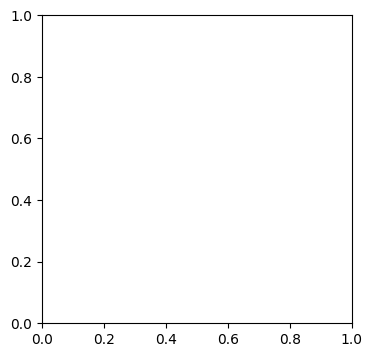

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te, pred_opt, display_labels=["Normal", "Anomaly"],
    cmap="Blues", ax=ax)
ax.set_title(f"Confusion matrix (thr={best_thr:.3f})", fontsize=11)
fig.tight_layout()
fig.savefig(f"{OUT_CI}/05_confusion_matrix.png", dpi=150)
plt.close(fig)

#### 6. Recall

NameError: name 'names' is not defined

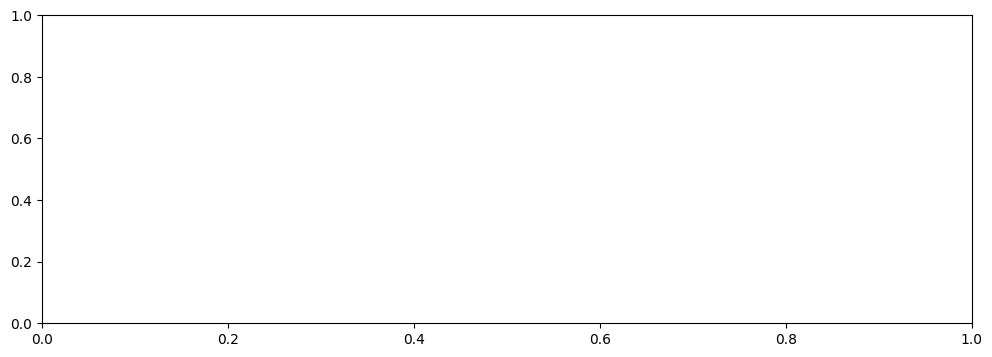

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
recalls = [results[k]["recall"] for k in names]
ax.bar(names, recalls,
       color=["#E45756" if n == best_name else "#F58518" for n in names])
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1.1); ax.set_ylabel("Recall (anomaly)")
ax.set_title("Anomaly Recall by technique")
fig.tight_layout()
fig.savefig(f"{OUT_CI}/06_recall_comparison.png", dpi=150)
plt.close(fig)

print(f"\n✅  02_class_imbalance.py complete. Plots → {OUT_CI}/")

---
## 3. Data Augmentation
Time-series augmentation applied **only to the minority (anomaly) class** in the
training split — never to the test set.

Techniques: jitter, scaling, magnitude warping, time warping, window slicing.

### Config

In [ ]:
print("=" * 65)
print("03 – DATA AUGMENTATION")
print("=" * 65)

03 – DATA AUGMENTATION


### Load

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/telemetry_labelled.csv")
feature_cols = [c for c in FEATURE_COLS if c in df.columns]
df = df.dropna(subset=feature_cols + ["Is_Anomaly"]).reset_index(drop=True)

X = df[feature_cols].values.astype(float)
y = df["Is_Anomaly"].values.astype(int)

print(f"\nSamples: {len(y):,}  |  Normal={np.sum(y==0):,}  |  Anomaly={np.sum(y==1):,}")

### Train / test split

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Work only with anomaly samples in train
X_min = X_tr[y_tr == 1]
n_min = len(X_min)
print(f"Anomaly samples in train: {n_min}")

# AUGMENTATION FUNCTIONS
# Each takes (X: np.ndarray [n_samples, n_features]) and returns augmented copy

def jitter(X, sigma=0.05):
    """Add Gaussian noise scaled to each feature's std."""
    stds  = X.std(axis=0, keepdims=True) + 1e-8
    noise = rng.standard_normal(X.shape) * sigma * stds
    return X + noise

def scaling(X, sigma=0.15):
    """Multiply each sample by a random scalar drawn per sample."""
    factors = rng.normal(loc=1.0, scale=sigma, size=(X.shape[0], 1))
    return X * factors

def magnitude_warping(X, sigma=0.2, n_knots=4):
    """
    Per-feature smooth random scaling curve (cubic-spline style via interp).
    """
    from scipy.interpolate import CubicSpline
    n_samples, n_features = X.shape
    result = X.copy()
    knot_x = np.linspace(0, n_samples - 1, n_knots)
    for f in range(n_features):
        knot_y = rng.normal(loc=1.0, scale=sigma, size=n_knots)
        cs     = CubicSpline(knot_x, knot_y)
        curve  = cs(np.arange(n_samples))
        result[:, f] *= curve
    return result

def time_warping(X, sigma=0.2, n_knots=4):
    """
    Smooth random time-axis distortion via cumulative warp path.
    """
    from scipy.interpolate import CubicSpline
    n_samples, n_features = X.shape
    knot_x = np.linspace(0, n_samples - 1, n_knots)
    knot_y = rng.normal(loc=1.0, scale=sigma, size=n_knots)
    cs     = CubicSpline(knot_x, knot_y)
    warp   = cs(np.arange(n_samples))
    # Build new time indices via cumulative warp
    warp_cumsum = np.cumsum(np.abs(warp))
    warp_cumsum = (warp_cumsum / warp_cumsum[-1]) * (n_samples - 1)
    result = np.zeros_like(X)
    for f in range(n_features):
        result[:, f] = np.interp(np.arange(n_samples), warp_cumsum, X[:, f])
    return result

def window_slicing(X, ratio=0.9):
    """
    Randomly crop a contiguous sub-window and resize back to original length.
    """
    n_samples, n_features = X.shape
    win_len   = max(2, int(n_samples * ratio))
    start     = rng.integers(0, n_samples - win_len + 1)
    sliced    = X[start : start + win_len, :]
    result    = np.zeros_like(X)
    old_idx   = np.linspace(0, win_len - 1, win_len)
    new_idx   = np.linspace(0, win_len - 1, n_samples)
    for f in range(n_features):
        result[:, f] = np.interp(new_idx, old_idx, sliced[:, f])
    return result

### Apply augmentations

In [ ]:
augmenters = {
    "Jitter"           : jitter,
    "Scaling"          : scaling,
    "Magnitude Warping": magnitude_warping,
    "Time Warping"     : time_warping,
    "Window Slicing"   : window_slicing,
}

print("\nApplying augmentations to anomaly class ...")
aug_samples = {}
for name, fn in augmenters.items():
    try:
        X_aug = fn(X_min.copy())
        aug_samples[name] = X_aug
        print(f"    [{name:<20s}]  generated {X_aug.shape[0]} new samples")
    except Exception as e:
        print(f"    [{name}] FAILED: {e}")

### Build augmented training set

In [ ]:
# Stack original train + all augmented anomaly copies
X_aug_all = np.vstack([X_min] + list(aug_samples.values()))
y_aug_all = np.ones(len(X_aug_all), dtype=int)

X_train_aug = np.vstack([X_tr, X_aug_all])
y_train_aug = np.concatenate([y_tr, y_aug_all])

n_normal_tr  = int(np.sum(y_train_aug == 0))
n_anomaly_tr = int(np.sum(y_train_aug == 1))
print(f"\nAugmented train set: {len(y_train_aug):,}  "
      f"(Normal={n_normal_tr:,}  Anomaly={n_anomaly_tr:,})")

### Evaluate: before vs after augmentation

In [ ]:
print("\nEvaluating effect of augmentation ...")
scaler = StandardScaler()

# Before
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)
clf_base = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                   random_state=RANDOM_STATE, n_jobs=-1)
clf_base.fit(X_tr_sc, y_tr)
pred_base = clf_base.predict(X_te_sc)
f1_base   = f1_score(y_te, pred_base, pos_label=1, zero_division=0)
try:
    auc_base = roc_auc_score(y_te, clf_base.predict_proba(X_te_sc)[:,1])
except Exception:
    auc_base = 0.5
print(f"    Before augmentation  →  F1={f1_base:.4f}  AUC={auc_base:.4f}")

# After
scaler2     = StandardScaler()
X_tr_aug_sc = scaler2.fit_transform(X_train_aug)
X_te_aug_sc = scaler2.transform(X_te)
clf_aug  = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                   n_jobs=-1)
clf_aug.fit(X_tr_aug_sc, y_train_aug)
pred_aug = clf_aug.predict(X_te_aug_sc)
f1_aug   = f1_score(y_te, pred_aug, pos_label=1, zero_division=0)
try:
    auc_aug = roc_auc_score(y_te, clf_aug.predict_proba(X_te_aug_sc)[:,1])
except Exception:
    auc_aug = 0.5
print(f"    After  augmentation  →  F1={f1_aug:.4f}  AUC={auc_aug:.4f}")
print(f"\n    Classification report (after augmentation):")
print(classification_report(y_te, pred_aug,
                             target_names=["Normal","Anomaly"],
                             zero_division=0))

### Save augmented dataset

In [ ]:
aug_df = pd.DataFrame(X_aug_all, columns=feature_cols)
aug_df["Is_Anomaly"] = 1
aug_df["Source"]     = np.repeat(
    ["original"] + list(aug_samples.keys()),
    [n_min] + [len(v) for v in aug_samples.values()]
)
aug_df.to_csv(f"{DATA_DIR}/telemetry_augmented.csv", index=False)
print(f"\nSaved {DATA_DIR}/telemetry_augmented.csv  ({len(aug_df):,} rows)")

### PLOTS

In [ ]:
print("\nGenerating plots ...")

#### 1. Compare original vs augmented for Speed channel

In [ ]:
fig, axes = plt.subplots(len(aug_samples), 2, figsize=(14, 3.5*len(aug_samples)))
if len(aug_samples) == 1:
    axes = axes[np.newaxis, :]

speed_idx = feature_cols.index("Speed") if "Speed" in feature_cols else 0
n_show    = min(2000, len(X_min))   # cap for plot readability

for i, (name, X_aug) in enumerate(aug_samples.items()):
    axes[i, 0].plot(X_min[:n_show, speed_idx], color="#4C78A8", lw=0.8)
    axes[i, 0].set_title("Original – Speed (anomaly samples)")
    axes[i, 0].set_ylabel("km/h")

    axes[i, 1].plot(X_aug[:n_show, speed_idx], color="#E45756", lw=0.8)
    axes[i, 1].set_title(f"{name} – Speed (augmented)")

fig.suptitle("Data Augmentation – Anomaly Lap (Speed channel)", fontsize=13)
fig.tight_layout()
fig.savefig(f"{OUT_AUG}/01_augmentation_comparison.png", dpi=150)
plt.close(fig)

#### 2. Feature distributions: original anomaly vs each augmentation

In [ ]:
fig, axes = plt.subplots(1, len(feature_cols),
                         figsize=(3.5 * len(feature_cols), 4))
if len(feature_cols) == 1:
    axes = [axes]

for j, feat in enumerate(feature_cols):
    axes[j].hist(X_min[:, j], bins=40, alpha=0.6,
                 label="Original", color="#4C78A8", density=True)
    for name, X_aug in aug_samples.items():
        if X_aug.ndim == 2 and X_aug.shape[1] == len(feature_cols):
            axes[j].hist(X_aug[:, j], bins=40, alpha=0.4,
                         label=name, density=True)
    axes[j].set_title(feat, fontsize=9)
    axes[j].set_xlabel("Value")
    if j == 0:
        axes[j].set_ylabel("Density")

axes[0].legend(fontsize=7)
fig.suptitle("Feature Distributions – Original vs Augmented (Anomaly class)",
             fontsize=12)
fig.tight_layout()
fig.savefig(f"{OUT_AUG}/02_feature_distributions.png", dpi=150)
plt.close(fig)

#### 3. F1 / AUC before vs after bar chart

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Before\nAugmentation", "After\nAugmentation"]
f1s  = [f1_base,  f1_aug]
aucs = [auc_base, auc_aug]
x = np.arange(2); w = 0.35
ax.bar(x - w/2, f1s,  w, label="F1 (anomaly)", color=["#4C78A8","#E45756"])
ax.bar(x + w/2, aucs, w, label="ROC-AUC",      color=["#72B7B2","#54A24B"])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1); ax.legend()
ax.set_title("Impact of Data Augmentation")
for xi, (f, a) in enumerate(zip(f1s, aucs)):
    ax.text(xi - w/2, f + 0.02, f"{f:.3f}", ha="center", fontsize=9)
    ax.text(xi + w/2, a + 0.02, f"{a:.3f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(f"{OUT_AUG}/03_before_after_augmentation.png", dpi=150)
plt.close(fig)

#### 4. Class balance before / after

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (title, n0, n1) in zip(axes, [
    ("Before augmentation", int(np.sum(y_tr==0)), int(np.sum(y_tr==1))),
    ("After augmentation",  n_normal_tr,           n_anomaly_tr),
]):
    ax.bar(["Normal","Anomaly"], [n0, n1], color=["#4C78A8","#E45756"])
    ax.set_title(title)
    ax.set_ylabel("Samples")
    for i, v in enumerate([n0, n1]):
        ax.text(i, v * 1.01, f"{v:,}", ha="center", fontsize=9)
fig.suptitle("Class Balance Before / After Augmentation", fontsize=12)
fig.tight_layout()
fig.savefig(f"{OUT_AUG}/04_class_balance.png", dpi=150)
plt.close(fig)

print(f"\n✅  03_data_augmentation.py complete. Plots → {OUT_AUG}/")

---
## 4. Data Imputation
Imputers fitted on the **training set only**, then applied to the test set.

Techniques: mean / median / mode / constant, LOCF / NOCB / linear interpolation,
KNN (k=3, k=5), MICE–BayesianRidge, MICE–RF, MissForest (optional).
Evaluation: RMSE on 10 % synthetic MCAR-masked test positions.

### Config

In [ ]:
print("=" * 65)
print("04 – DATA IMPUTATION")
print("=" * 65)

### Load

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/telemetry_labelled.csv")
feature_cols = [c for c in FEATURE_COLS if c in df.columns]
df_num = df[feature_cols].copy()
print(f"\nShape: {df_num.shape}  |  Features: {feature_cols}")

# Assess real missingness
real_missing = df_num.isna().sum()
print(f"\nReal missing values per column:\n{real_missing.to_string()}")
missing_pct = df_num.isna().mean() * 100
print(f"\nMissing %:\n{missing_pct.round(2).to_string()}")

# Missingness type discussion
print("\n[Missingness type analysis]")
print("  FastF1 telemetry NaNs arise from interpolation gaps and sensor dropouts.")
print("  This is consistent with MCAR (random sensor gaps) or MAR (speed-dependent")
print("  DRS readings). We proceed assuming MAR and apply imputation accordingly.")

### Train / test split (imputer fitted on train only!)

In [ ]:
df_complete = df_num.dropna()
print(f"\nComplete rows for evaluation: {len(df_complete):,}")

X_tr_raw, X_te_raw = train_test_split(
    df_complete.values.astype(float),
    test_size=0.20, random_state=RANDOM_STATE
)

# Introduce synthetic MCAR missingness (10%) on train and test separately
def mask_mcar(X, rate=MISSING_RATE):
    m = rng.random(X.shape) < rate
    Xm = X.copy()
    Xm[m] = np.nan
    return Xm, m

X_tr_miss, mask_tr = mask_mcar(X_tr_raw)
X_te_miss, mask_te = mask_mcar(X_te_raw)

print(f"\nSynthetic {MISSING_RATE*100:.0f}% MCAR missingness applied.")
print(f"  Train masked: {mask_tr.sum():,}  |  Test masked: {mask_te.sum():,}")

### Time-series helpers (no fit/transform — state-free)

In [ ]:
def locf(X):
    df_ = pd.DataFrame(X)
    return df_.ffill().bfill().values

def nocb(X):
    df_ = pd.DataFrame(X)
    return df_.bfill().ffill().values

def linear_interp(X):
    df_ = pd.DataFrame(X)
    return df_.interpolate(method="linear", limit_direction="both").values

### Imputers dict

In [ ]:
sklearn_imputers = {
    "Mean"              : SimpleImputer(strategy="mean"),
    "Median"            : SimpleImputer(strategy="median"),
    "Mode"              : SimpleImputer(strategy="most_frequent"),
    "Constant (0)"      : SimpleImputer(strategy="constant", fill_value=0),
    "KNN (k=3)"         : KNNImputer(n_neighbors=3),
    "KNN (k=5)"         : KNNImputer(n_neighbors=5),
    "MICE – BayesRidge" : IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=10, random_state=RANDOM_STATE),
    "MICE – RF"         : IterativeImputer(
                              estimator=RandomForestRegressor(
                                  n_estimators=30, random_state=RANDOM_STATE,
                                  n_jobs=-1),
                              max_iter=5, random_state=RANDOM_STATE),
}

ts_imputers = {
    "LOCF"          : locf,
    "NOCB"          : nocb,
    "Linear Interp" : linear_interp,
}

### Evaluate: fit on train, transform on test

In [ ]:
print("\n[Evaluating imputers — fitted on train, evaluated on test] ...")
rmse_results = {}

for name, imp in sklearn_imputers.items():
    try:
        imp.fit(X_tr_miss)
        X_te_imp = imp.transform(X_te_miss)
        # RMSE only on masked positions in test
        rmse = float(np.sqrt(mean_squared_error(
            X_te_raw[mask_te], X_te_imp[mask_te]
        )))
        rmse_results[name] = rmse
        print(f"    {name:<25s}  RMSE = {rmse:.4f}")
    except Exception as e:
        print(f"    {name:<25s}  FAILED: {e}")

for name, fn in ts_imputers.items():
    try:
        # TS methods are state-free: applied directly to test
        X_te_imp = fn(X_te_miss)
        rmse = float(np.sqrt(mean_squared_error(
            X_te_raw[mask_te], X_te_imp[mask_te]
        )))
        rmse_results[name] = rmse
        print(f"    {name:<25s}  RMSE = {rmse:.4f}")
    except Exception as e:
        print(f"    {name:<25s}  FAILED: {e}")

# Optional: MissForest (if installed)
try:
    from missforest import MissForest
    mf = MissForest()
    X_tr_mf = pd.DataFrame(X_tr_miss, columns=feature_cols)
    X_te_mf = pd.DataFrame(X_te_miss, columns=feature_cols)
    X_tr_mf_imp = mf.fit_transform(X_tr_mf)
    X_te_mf_imp = mf.transform(X_te_mf).values
    rmse_mf = float(np.sqrt(mean_squared_error(
        X_te_raw[mask_te], X_te_mf_imp[mask_te]
    )))
    rmse_results["MissForest"] = rmse_mf
    print(f"    {'MissForest':<25s}  RMSE = {rmse_mf:.4f}")
except ImportError:
    print("    MissForest not installed — skipping (pip install missforest)")
except Exception as e:
    print(f"    MissForest FAILED: {e}")

### Best method

In [ ]:
best_method = min(rmse_results, key=rmse_results.get)
print(f"\n[Best method] {best_method}  RMSE={rmse_results[best_method]:.4f}")

# Save RMSE table
rmse_df = pd.Series(rmse_results, name="RMSE").sort_values()
rmse_df.to_csv(f"{OUT_IMP}/rmse_results.csv", header=True)
print(rmse_df.to_string())

### Apply best imputer to full dataset

In [ ]:
print(f"\nApplying '{best_method}' to full dataset ...")
df_full_num = df_num.values.astype(float)

if best_method in sklearn_imputers:
    best_imp = sklearn_imputers[best_method]
    best_imp.fit(df_full_num)
    df_imputed_vals = best_imp.transform(df_full_num)
elif best_method == "LOCF":
    df_imputed_vals = locf(df_full_num)
elif best_method == "NOCB":
    df_imputed_vals = nocb(df_full_num)
elif best_method == "Linear Interp":
    df_imputed_vals = linear_interp(df_full_num)
else:
    df_imputed_vals = linear_interp(df_full_num)  # fallback

df_imputed = pd.DataFrame(df_imputed_vals, columns=feature_cols)

### Missingness indicator variables

In [ ]:
for col in feature_cols:
    df_imputed[f"{col}_missing"] = df_num[col].isna().astype(int)

# Merge back non-numeric columns
non_numeric = [c for c in df.columns if c not in feature_cols]
df_final = pd.concat([
    df[non_numeric].reset_index(drop=True),
    df_imputed.reset_index(drop=True)
], axis=1)

df_final.to_csv(f"{DATA_DIR}/telemetry_imputed.csv", index=False)
print(f"Saved {DATA_DIR}/telemetry_imputed.csv  {df_final.shape}")

### PLOTS

In [ ]:
print("\nGenerating plots ...")

#### 1. RMSE comparison

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
names_sorted = list(rmse_df.index)
vals_sorted  = list(rmse_df.values)
colors = ["#E45756" if n == best_method else "#4C78A8" for n in names_sorted]
bars = ax.bar(names_sorted, vals_sorted, color=colors)
ax.set_ylabel("RMSE")
ax.set_title(f"Imputation RMSE on 10% masked test data  (red = best)", fontsize=13)
ax.set_xticklabels(names_sorted, rotation=35, ha="right", fontsize=8)
for bar, val in zip(bars, vals_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7)
fig.tight_layout()
fig.savefig(f"{OUT_IMP}/01_rmse_comparison.png", dpi=150)
plt.close(fig)

#### 2. Missingness heatmap (first 500 rows)

In [ ]:
sample_miss = df_num.iloc[:500].isna().astype(int)
if sample_miss.values.any():
    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(sample_miss.T, aspect="auto", cmap="Reds",
                   interpolation="none")
    ax.set_yticks(range(len(feature_cols)))
    ax.set_yticklabels(feature_cols)
    ax.set_xlabel("Sample index (first 500 rows)")
    ax.set_title("Missingness heatmap (red = missing)")
    fig.colorbar(im, ax=ax, shrink=0.6)
    fig.tight_layout()
    fig.savefig(f"{OUT_IMP}/02_missingness_heatmap.png", dpi=150)
    plt.close(fig)
else:
    print("    No real missing values in first 500 rows — skipping heatmap.")

#### 3. Speed: original vs imputed (300 rows)

In [ ]:
n_plot = min(300, len(df_num))
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(df_num["Speed"].iloc[:n_plot].values, color="#4C78A8", lw=0.8)
axes[0].set_title("Speed – original (NaN visible as gaps)")
axes[0].set_ylabel("Speed (km/h)")
axes[1].plot(df_imputed["Speed"].iloc[:n_plot].values, color="#E45756", lw=0.8)
axes[1].set_title(f"Speed – after '{best_method}' imputation")
axes[1].set_ylabel("Speed (km/h)"); axes[1].set_xlabel("Sample index")
fig.suptitle("Data Imputation – Speed Channel", fontsize=13)
fig.tight_layout()
fig.savefig(f"{OUT_IMP}/03_speed_before_after.png", dpi=150)
plt.close(fig)

#### 4. Distribution shift per feature

In [ ]:
fig, axes = plt.subplots(1, len(feature_cols),
                         figsize=(3.5*len(feature_cols), 4))
if len(feature_cols) == 1:
    axes = [axes]
for j, feat in enumerate(feature_cols):
    orig_vals = df_num[feat].dropna()
    imp_vals  = df_imputed[feat]
    axes[j].hist(orig_vals, bins=40, alpha=0.6, density=True,
                 label="Original", color="#4C78A8")
    axes[j].hist(imp_vals,  bins=40, alpha=0.5, density=True,
                 label="Imputed",  color="#E45756")
    axes[j].set_title(feat, fontsize=9)
    axes[j].set_xlabel("Value")
    if j == 0:
        axes[j].set_ylabel("Density")
axes[0].legend(fontsize=8)
fig.suptitle(f"Feature Distributions – Original vs Imputed ({best_method})",
             fontsize=12)
fig.tight_layout()
fig.savefig(f"{OUT_IMP}/04_distribution_shift.png", dpi=150)
plt.close(fig)

print(f"\n✅  04_data_imputation.py complete. Plots → {OUT_IMP}/")